In [1]:
#Новый датасет


In [2]:
pip list


Package                   Version
------------------------- -----------
aiohappyeyeballs          2.6.1
aiohttp                   3.13.3
aiosignal                 1.4.0
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.0.5
attrs                     25.4.0
babel                     2.17.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.1.4
cffi                      2.0.0
charset-normalizer        3.4.4
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.19
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
filelock                  3.20.3
fonttools                 4.61.1
fqdn                      1.5.1
frozenlist                1.8.0
fsspec           

In [1]:
from src.pdb.PDBFile import PDBFile
from tqdm import tqdm
from src.preprocessing.interpolation import resample_trajectory, resample_trajectory_cubic_spline
from src.preprocessing.curves import get_invariant_features
import numpy as np
from torch.utils.data import Dataset, DataLoader
from src.models.vae import ConvVAE
import torch.optim as optim
import torch
import torch.nn.functional as F
import warnings
import os
from src.metrics.vae_loss import vae_loss


warnings.filterwarnings('ignore')


K = 1024

In [2]:
PDB_FILE_ARRAY = []
CA_POINT_ARRAY = []

import os
zero_error_count = 0
for root, dirs, files in os.walk('data/dataset_10000_1_filtered'):
    for file in tqdm(files):
        file_path = os.path.join(root, file)
        pdb_file = PDBFile(file_path)
        if len(pdb_file.atom_line) > 0:
            ca_point = pdb_file.get_point_cloud()
            PDB_FILE_ARRAY.append(pdb_file)
            CA_POINT_ARRAY.append(ca_point)
        else: 
            zero_error_count += 1

0it [00:00, ?it/s]
  3%|█████                                                                                                                                                                                                | 140/5390 [00:00<00:16, 326.59it/s]

ERROR! Length atom_line = 0!!!
data/dataset_10000_1_filtered/domains/5unh_A_3.pdb
Not Found CA atoms
ERROR! Length atom_line = 0!!!
data/dataset_10000_1_filtered/domains/2vb9_B_2.pdb
Not Found CA atoms


  5%|█████████▋                                                                                                                                                                                           | 264/5390 [00:00<00:14, 344.48it/s]

ERROR! Length atom_line = 0!!!
data/dataset_10000_1_filtered/domains/5m63_M_2.pdb
Not Found CA atoms


  8%|████████████████▌                                                                                                                                                                                    | 452/5390 [00:01<00:17, 283.45it/s]

...

 97%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎      | 5205/5390 [00:20<00:00, 360.49it/s]

ERROR! Length atom_line = 0!!!
data/dataset_10000_1_filtered/domains/2vb9_A_1.pdb
Not Found CA atoms
ERROR! Length atom_line = 0!!!
data/dataset_10000_1_filtered/domains/7p7j_I_1.pdb
Not Found CA atoms


 99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍  | 5320/5390 [00:20<00:00, 356.17it/s]

ERROR! Length atom_line = 0!!!
data/dataset_10000_1_filtered/domains/6f5i_D_1.pdb
Not Found CA atoms


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5390/5390 [00:20<00:00, 259.53it/s]


In [3]:
resampled_coords = []
for example in tqdm(CA_POINT_ARRAY):
    resampled_coords.append(resample_trajectory_cubic_spline(get_invariant_features(np.array(example)), k = 1024)
)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5329/5329 [00:27<00:00, 197.19it/s]


In [4]:
from src.data.dataset import Trajectories_dataset

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
from src.utils.config_loader import project_config
config = project_config.load()  

In [7]:
train_data_raw, val_data_raw = train_test_split(
    resampled_coords,       
    test_size=config.get('training', {}).get('validation_split', 0.1),  
    random_state=42 
)

In [9]:
device = config.get('model', {}).get('device', 'cpu')
learning_rate = config.get('training', {}).get('learning_rate', 0.1)
num_epochs = config.get('training', {}).get('epochs', 100)
batch_size = config.get('training', {}).get('batch_size', 16)

In [10]:
kl_weight_start = 0.01
kl_weight_end = 1
kl_anneal_epochs = 100

In [11]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import math


In [12]:
train_dataset = Trajectories_dataset(train_data_raw, normalize=True)
val_dataset = Trajectories_dataset(val_data_raw, normalize=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
model = ConvVAE(latent_dim = 16).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [13]:
train_dataset[0][0].shape

torch.Size([1024, 3])

In [14]:
train_losses = []
val_losses = []
train_recon_losses = []
val_recon_losses = []
train_kl_losses = []
val_kl_losses = []
train_mse_losses = []
val_mse_losses = []


In [15]:
print('Начало обучения VAE с KL Annealing')
for epoch in range(num_epochs):
    if epoch < kl_anneal_epochs:
        kl_weight = kl_weight_start + (kl_weight_end - kl_weight_start) * (epoch / kl_anneal_epochs)
    else:
        kl_weight = kl_weight_end

    model.train()
    train_total_loss = 0
    train_recon_loss = 0
    train_kl_loss = 0
    train_mse = 0
    
    for batch in train_loader:
        signals = batch[0].to(device) 
        
        reconstructed, mu, logvar, z = model(signals)
        
        total_loss, recon_loss, kl_loss = vae_loss(
            reconstructed, signals, mu, logvar, 
            recon_weight=1.0, kl_weight=kl_weight
        )
        
        mse_loss = F.mse_loss(reconstructed, signals, reduction='mean')

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        train_total_loss += total_loss.item()
        train_recon_loss += recon_loss.item()
        train_kl_loss += kl_loss.item()
        train_mse += mse_loss.item()
    
    model.eval()
    val_total_loss = 0
    val_recon_loss = 0
    val_kl_loss = 0
    val_mse = 0
    
    with torch.no_grad():
        for batch in val_loader:
            signals = batch[0].to(device)  
            reconstructed, mu, logvar, z = model(signals)

            total_loss, recon_loss, kl_loss = vae_loss(
                reconstructed, signals, mu, logvar,
                recon_weight=1.0, kl_weight=kl_weight
            )
            
            mse_loss = F.mse_loss(reconstructed, signals, reduction='mean')
            
            val_total_loss += total_loss.item()
            val_recon_loss += recon_loss.item()
            val_kl_loss += kl_loss.item()
            val_mse += mse_loss.item()
    
    # Усреднение лоссов
    avg_train_total = train_total_loss / len(train_loader)
    avg_train_recon = train_recon_loss / len(train_loader)
    avg_train_kl = train_kl_loss / len(train_loader)
    avg_train_mse = train_mse / len(train_loader)
    
    avg_val_total = val_total_loss / len(val_loader)
    avg_val_recon = val_recon_loss / len(val_loader)
    avg_val_kl = val_kl_loss / len(val_loader)
    avg_val_mse = val_mse / len(val_loader)
        
    if ((epoch + 1) % 20 == 0) or (epoch == 0):
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'  Train - Total: {avg_train_total:.6f} | Recon: {avg_train_recon:.6f} | KL (unweighted): {avg_train_kl:.6f} | MSE: {avg_train_mse:.6f}')
        print(f'  Val   - Total: {avg_val_total:.6f} | Recon: {avg_val_recon:.6f} | KL (unweighted): {avg_val_kl:.6f} | MSE: {avg_val_mse:.6f}')
        print(f'  Current KL Weight: {kl_weight:.6f}') # Вывод текущего веса
        print('-' * 80)

Начало обучения VAE с KL Annealing
Epoch [1/500]
  Train - Total: 2684.972002 | Recon: 2578.725409 | KL (unweighted): 10624.660896 | MSE: 0.026242
  Val   - Total: 1285.873668 | Recon: 1211.152441 | KL (unweighted): 7472.122243 | MSE: 0.012613
  Current KL Weight: 0.010000
--------------------------------------------------------------------------------
Epoch [20/500]
  Train - Total: 1147.782572 | Recon: 940.331066 | KL (unweighted): 1047.205992 | MSE: 0.009574
  Val   - Total: 1314.466143 | Recon: 1104.843312 | KL (unweighted): 1058.166691 | MSE: 0.011487
  Current KL Weight: 0.198100
--------------------------------------------------------------------------------
Epoch [40/500]
  Train - Total: 1157.917164 | Recon: 796.902860 | KL (unweighted): 911.422086 | MSE: 0.008113
  Val   - Total: 1535.307746 | Recon: 1187.967393 | KL (unweighted): 876.900631 | MSE: 0.012336
  Current KL Weight: 0.396100
--------------------------------------------------------------------------------
Epoch [60

KeyboardInterrupt: 

In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, channels, dilation, kernel_size=3):
        super(ResidualBlock, self).__init__()
        padding = dilation * (kernel_size - 1) // 2
        
        self.conv = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, 
                      padding=padding, dilation=dilation),
            nn.BatchNorm1d(channels),
            nn.ReLU(True),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.BatchNorm1d(channels)
        )
        self.relu = nn.ReLU(True)

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out += residual
        return self.relu(out)

class ResConvModel(nn.Module):
    def __init__(self, input_channels=3, sequence_length=1024, latent_dim=256, dropout_rate=0.05):
        super(ResConvModel, self).__init__()
        
        self.initial_conv = nn.Conv1d(input_channels, 32, kernel_size=7, padding=3)
        
        self.enc_layers = nn.ModuleList([
            ResidualBlock(32, dilation=1),
            nn.Conv1d(32, 64, kernel_size=4, stride=2, padding=1),
            
            ResidualBlock(64, dilation=2),
            nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1), 
            
            ResidualBlock(128, dilation=4),
            nn.Conv1d(128, 256, kernel_size=4, stride=2, padding=1), 
            
            ResidualBlock(256, dilation=8),
            nn.Conv1d(256, 512, kernel_size=4, stride=2, padding=1), 
            
            ResidualBlock(512, dilation=16),
            nn.Conv1d(512, 512, kernel_size=4, stride=2, padding=1),
        ])
        
        self.final_length = sequence_length // (2**5) 
        self.encoded_size = 512 * self.final_length 
        
        self.latent_layer = nn.Linear(self.encoded_size, latent_dim)
        self.decoder_input = nn.Linear(latent_dim, self.encoded_size)

        self.dec_layers = nn.ModuleList([
            nn.Upsample(scale_factor=2, mode='linear', align_corners=True), 
            nn.Conv1d(512, 512, kernel_size=3, padding=1),
            DilatedResidualBlock(512, dilation=8),
            
            nn.Upsample(scale_factor=2, mode='linear', align_corners=True), 
            nn.Conv1d(512, 256, kernel_size=3, padding=1),
            DilatedResidualBlock(256, dilation=4),
            
            nn.Upsample(scale_factor=2, mode='linear', align_corners=True), 
            nn.Conv1d(256, 128, kernel_size=3, padding=1),
            DilatedResidualBlock(128, dilation=2),
            
            nn.Upsample(scale_factor=2, mode='linear', align_corners=True), 
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            DilatedResidualBlock(64, dilation=1),
            
            nn.Upsample(scale_factor=2, mode='linear', align_corners=True),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
        ])
        self.final_out = nn.Sequential(
            nn.Conv1d(32, input_channels, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.initial_conv(x)
        for layer in self.enc_layers:
            x = layer(x)
        x = x.view(x.size(0), -1)
        return self.latent_layer(x)

    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(x.size(0), 512, self.final_length)
        for layer in self.dec_layers:
            x = layer(x)
        return self.final_out(x)

    def forward(self, x):
        x = x.transpose(1, 2)
        latent = self.encode(x)
        reconstructed = self.decode(latent)
        return reconstructed.transpose(1, 2), latent

In [ ]:
def compute_loss(reconstructed, target):
    mse_loss = F.mse_loss(reconstructed, target)
    v_reconstructed = reconstructed[:, 1:, :] - reconstructed[:, :-1, :]
    v_target = target[:, 1:, :] - target[:, :-1, :]
    velocity_loss = F.mse_loss(v_reconstructed, v_target)
    
    return mse_loss 

In [62]:
train_dataset = Trajectories_dataset(train_data_raw, normalize=True)
val_dataset = Trajectories_dataset(val_data_raw, normalize=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
model = DilConv(sequence_length = 1024, latent_dim = 128).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [63]:
def loss(reconstructed, target):
    mse_loss = F.mse_loss(reconstructed, target)
    
    diff_reconstructed = reconstructed[:, 1:, :] - reconstructed[:, :-1, :]
    diff_target = target[:, 1:, :] - target[:, :-1, :]
    velocity_loss = F.mse_loss(diff_reconstructed, diff_target)
    
    return mse_loss + velocity_loss

In [64]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

train_losses = []
val_losses = []
train_recon_losses = []
val_recon_losses = []

print('Начало обучения автокодировщика')

patience = 15 
best_val_loss = float('inf')
epochs_without_improvement = 0

for epoch in range(num_epochs):
    model.train()
    train_total_loss = 0
    train_recon_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False)
    
    for batch in train_bar:
        signals = batch[0].to(device)
        
        reconstructed, latent = model(signals)
        
        recon_loss = compute_loss(reconstructed, signals)
        total_loss = recon_loss
        
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_total_loss += total_loss.item()
        train_recon_loss += recon_loss.item()
        
        train_bar.set_postfix({'Loss': f'{total_loss.item():.4f}'})
    
    model.eval()
    val_total_loss = 0
    val_recon_loss = 0
    
    val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]', leave=False)
    
    with torch.no_grad():
        for batch in val_bar:
            signals = batch[0].to(device)
            
            reconstructed, latent = model(signals)
            
            recon_loss = F.mse_loss(reconstructed, signals, reduction='mean')
            total_loss = recon_loss
            
            val_total_loss += total_loss.item()
            val_recon_loss += recon_loss.item()
            
            val_bar.set_postfix({'Loss': f'{total_loss.item():.4f}'})
    
    avg_train_total = train_total_loss / len(train_loader)
    avg_train_recon = train_recon_loss / len(train_loader)
    
    avg_val_total = val_total_loss / len(val_loader)
    avg_val_recon = val_recon_loss / len(val_loader)
    
    train_losses.append(avg_train_total)
    val_losses.append(avg_val_total)
    train_recon_losses.append(avg_train_recon)
    val_recon_losses.append(avg_val_recon)
    
    print(f'\nEpoch [{epoch+1}/{num_epochs}]')
    print(f'  Train - Loss: {avg_train_total:.6f} | Recon: {avg_train_recon:.6f}')
    print(f'  Val   - Loss: {avg_val_total:.6f} | Recon: {avg_val_recon:.6f}')
    
    is_best = avg_val_total < best_val_loss
    improvement = best_val_loss - avg_val_total
    
    if is_best:
        best_val_loss = avg_val_total
        epochs_without_improvement = 0
        
        # Сохранение лучшей модели
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_train_total,
            'val_loss': avg_val_total,
            'best_val_loss': best_val_loss,
        }, 'best_autoencoder.pth')
        print(f'  ✓ Сохранена лучшая модель (val loss: {avg_val_total:.6f}, улучшение: {improvement:.6f})')
    else:
        epochs_without_improvement += 1
        print(f'  Вариация: {improvement:.6f} (без улучшения: {epochs_without_improvement}/{patience})')
    
    if epochs_without_improvement >= patience:
        print(f'  ⏹ Ранняя остановка после {epoch+1} эпох')
        print(f'     Лучший val loss: {best_val_loss:.6f}')
        break
    
    if torch.isnan(torch.tensor(avg_val_total)):
        print('Обнаружен NaN в лоссе, остановка обучения')
        break
    
    print('-' * 80)

print(f'\nОбучение завершено за {epoch+1} эпох!')
print(f'Лучший валидационный loss: {best_val_loss:.6f}')

Начало обучения автокодировщика



Epoch [1/500]
  Train - Loss: 0.021856 | Recon: 0.021856
  Val   - Loss: 0.015336 | Recon: 0.015336
  ✓ Сохранена лучшая модель (val loss: 0.015336, улучшение: inf)
--------------------------------------------------------------------------------



Epoch [2/500]
  Train - Loss: 0.010930 | Recon: 0.010930
  Val   - Loss: 0.011466 | Recon: 0.011466
  ✓ Сохранена лучшая модель (val loss: 0.011466, улучшение: 0.003870)
--------------------------------------------------------------------------------



Epoch [3/500]
  Train - Loss: 0.006682 | Recon: 0.006682
  Val   - Loss: 0.005134 | Recon: 0.005134
  ✓ Сохранена лучшая модель (val loss: 0.005134, улучшение: 0.006332)
--------------------------------------------------------------------------------



Epoch [4/500]
  Train - Loss: 0.004109 | Recon: 0.004109
  Val   - Loss: 0.004452 | Recon: 0.004452
  ✓ Сохранена лучшая модель (val loss: 0.004452, улучшение: 0.000682)
--------------------------------------------------------------------------------


...


Epoch [86/500]
  Train - Loss: 0.000275 | Recon: 0.000275
  Val   - Loss: 0.000696 | Recon: 0.000696
  Вариация: -0.000050 (без улучшения: 11/15)
--------------------------------------------------------------------------------



Epoch [87/500]
  Train - Loss: 0.000288 | Recon: 0.000288
  Val   - Loss: 0.000716 | Recon: 0.000716
  Вариация: -0.000071 (без улучшения: 12/15)
--------------------------------------------------------------------------------



Epoch [88/500]
  Train - Loss: 0.000308 | Recon: 0.000308
  Val   - Loss: 0.000729 | Recon: 0.000729
  Вариация: -0.000084 (без улучшения: 13/15)
--------------------------------------------------------------------------------



Epoch [89/500]
  Train - Loss: 0.000330 | Recon: 0.000330
  Val   - Loss: 0.000907 | Recon: 0.000907
  Вариация: -0.000262 (без улучшения: 14/15)
--------------------------------------------------------------------------------



Epoch [90/500]
  Train - Loss: 0.000333 | Recon: 0.000333
  Val   - Loss: 0.000785 | Recon: 0.000785
  Вариация: -0.000140 (без улучшения: 15/15)
  ⏹ Ранняя остановка после 90 эпох
     Лучший val loss: 0.000645

Обучение завершено за 90 эпох!
Лучший валидационный loss: 0.000645


In [29]:
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 12.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 55.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 21.0 MB/s eta 0:00:00a 0:00:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.1 MB/s eta 0:00:0000:01m00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 21.3 MB/s eta 0:00:0000:0100:01


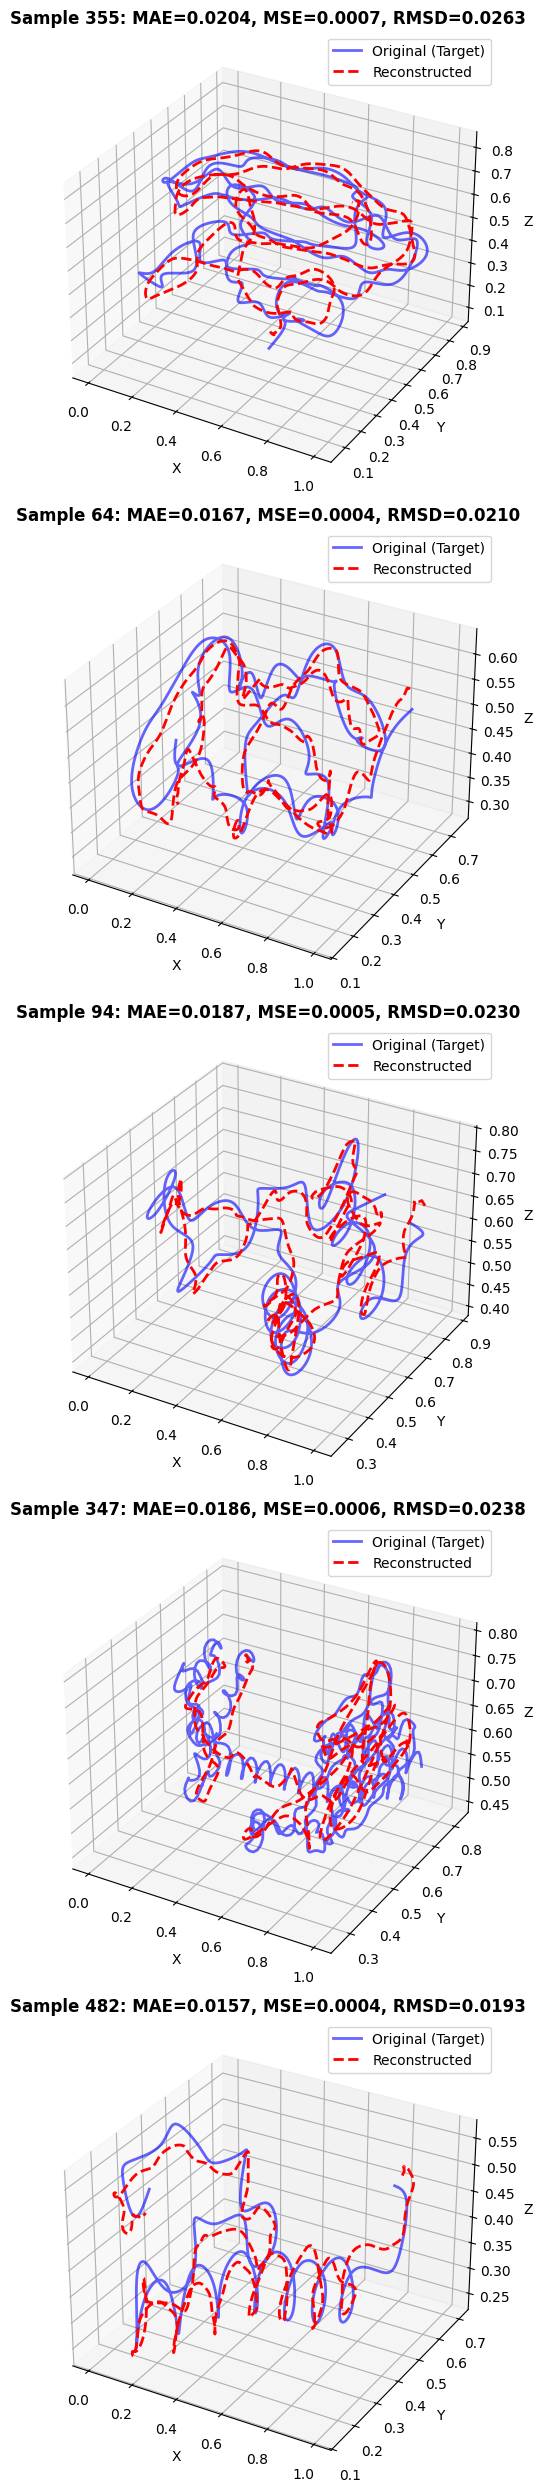

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

def visualize_reconstruction(model, dataset, num_samples=3, device='cpu'):
    model.eval()
    model.to(device)
    
    # Выбираем случайные индексы
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig = plt.figure(figsize=(15, 5 * num_samples))
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            original_input, target_curve = dataset[idx]
            
            input_tensor = original_input.unsqueeze(0).to(device)
            
            reconstructed_curve, latent = model(input_tensor)
            
            target_tensor = target_tensor = target_curve.unsqueeze(0).to(device)
            recon_tensor = reconstructed_curve
            
            mae = F.l1_loss(recon_tensor, target_tensor).item()
            
            mse = F.mse_loss(recon_tensor, target_tensor).item()
            
            rmsd = torch.sqrt(F.mse_loss(recon_tensor, target_tensor)).item()
            
            orig = target_curve.cpu().numpy() # Оригинал (целевой)
            recon = reconstructed_curve.squeeze(0).cpu().numpy() # Восстановленный

            ax = fig.add_subplot(num_samples, 1, i + 1, projection='3d')
            
            ax.plot(orig[:, 0], orig[:, 1], orig[:, 2], 
                   label='Original (Target)', color='blue', alpha=0.6, lw=2)
            
            ax.plot(recon[:, 0], recon[:, 1], recon[:, 2], 
                   label='Reconstructed', color='red', linestyle='--', lw=2)
            
            ax.set_title(f"Sample {idx}: MAE={mae:.4f}, MSE={mse:.4f}, RMSD={rmsd:.4f}", 
                        fontsize=12, fontweight='bold')
            ax.legend()
            
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_zlabel('Z')

    plt.tight_layout()
    plt.show()

metrics = visualize_reconstruction(model, val_dataset, num_samples=5, device=device)